# Simple Match Outcome Probabilities

We model goals scored by Team A and Team B as independent random variables:

$$
P(X_A=i, X_B=j) = P(X_A=i)P(X_B=j)
$$

Using this joint PMF on a finite goal range (0..9), we compute:

- `P(A wins) = \\sum_{i>j} P(X_A=i, X_B=j)`
- `P(tie) = \\sum_{i=j} P(X_A=i, X_B=j)`
- `P(B wins) = \\sum_{j>i} P(X_A=i, X_B=j)`

Below, we define reasonable prior PMFs for three team-strength groups: **strong**, **mid**, and **weak**.

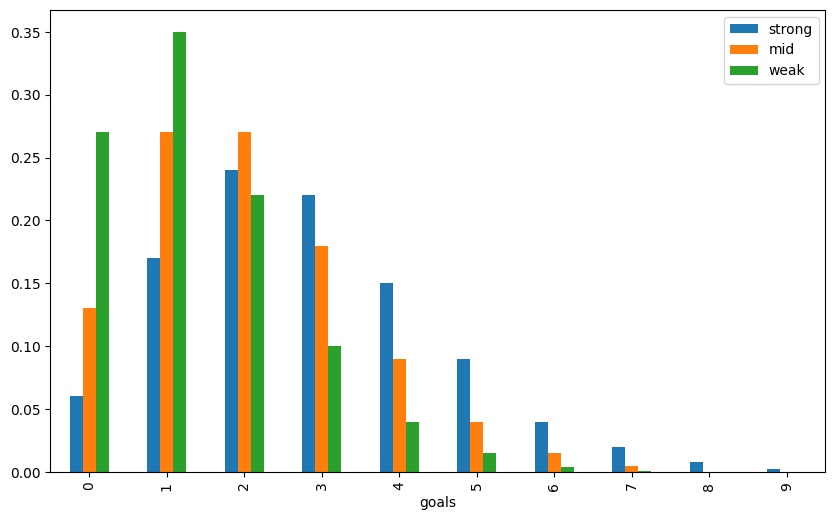

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Finite support for goals: 0..9 (as in setup notes)
goals = np.arange(10)

# Handcrafted, reasonable priors for goal counts by team strength.
# Each vector is a PMF over goals 0..9, then normalized for safety.
pmf_raw = {
    "strong": np.array([0.06, 0.17, 0.24, 0.22, 0.15, 0.09, 0.04, 0.02, 0.008, 0.002]),
    "mid":    np.array([0.13, 0.27, 0.27, 0.18, 0.09, 0.04, 0.015, 0.005, 0.000, 0.000]),
    "weak":   np.array([0.27, 0.35, 0.22, 0.10, 0.04, 0.015, 0.004, 0.001, 0.000, 0.000]),
}

pmf = {k: v / v.sum() for k, v in pmf_raw.items()}

pmf_table = pd.DataFrame(pmf, index=goals)
pmf_table.index.name = "goals"
pmf_table.plot(kind="bar", stacked=False, figsize=(10, 6))
plt.show()

In [3]:
def outcome_probabilities(p_a: np.ndarray, p_b: np.ndarray):
    """Return P(A win), P(tie), P(B win) from independent priors."""
    joint = np.outer(p_a, p_b)  # joint[i, j] = P(X_A=i, X_B=j)
    a_win = np.tril(joint, k=-1).sum()  # i > j region
    tie = np.trace(joint)               # i == j
    b_win = np.triu(joint, k=1).sum()   # j > i region
    assert a_win + tie + b_win - 1 < 1e-6, "Probabilities must sum to 1"
    return a_win, tie, b_win

rows = []
for group_a in ["strong", "mid", "weak"]:
    for group_b in ["strong", "mid", "weak"]:
        a_win, tie, b_win = outcome_probabilities(pmf[group_a], pmf[group_b])
        rows.append({
            "Team A group": group_a,
            "Team B group": group_b,
            "P(A wins)": a_win,
            "P(tie)": tie,
            "P(B wins)": b_win,
            "Check sum": a_win + tie + b_win,
        })

results = pd.DataFrame(rows)
results[["P(A wins)", "P(tie)", "P(B wins)", "Check sum"]] = (
    results[["P(A wins)", "P(tie)", "P(B wins)", "Check sum"]].round(4)
)
results

,Team A group,Team B group,P(A wins),P(tie),P(B wins),Check sum
0,strong,strong,0.4144,0.1712,0.4144,1.0
1,strong,mid,0.5467,0.1759,0.2774,1.0
2,strong,weak,0.6785,0.1580,0.1635,1.0
3,mid,strong,0.2774,0.1759,0.5467,1.0
4,mid,mid,0.3975,0.2050,0.3975,1.0
5,mid,weak,0.5352,0.2113,0.2535,1.0
6,weak,strong,0.1635,0.1580,0.6785,1.0
7,weak,mid,0.2535,0.2113,0.5352,1.0
8,weak,weak,0.3722,0.2556,0.3722,1.0


In [4]:
# Example: one specific matchup
a_group = "strong"
b_group = "weak"
a_win, tie, b_win = outcome_probabilities(pmf[a_group], pmf[b_group])

print(f"A={a_group}, B={b_group}")
print(f"P(A wins) = {a_win:.4f}")
print(f"P(tie)    = {tie:.4f}")
print(f"P(B wins) = {b_win:.4f}")
print(f"Total      = {a_win + tie + b_win:.4f}")

A=strong, B=weak
P(A wins) = 0.6785
P(tie)    = 0.1580
P(B wins) = 0.1635
Total      = 1.0000
